In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_sasa)=
# Get SASA

*Computing solvent-accessible surface area (SASA) for atoms and residues.*

The function {func}`molsysmt.physchem.get_sasa` evaluates solvent-accessible surface areas using numerical rolling-probe sphere algorithms (e.g. Shrake-Rupley / Lee-Richards).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.physchem.get_sasa`.
:::


## Basic usage

Let's compute the solvent-accessible surface area per residue for a protein structure:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['Trp-Cage']['1l2y.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute the SASA per residue group and plot the solvent exposure profile along the peptide sequence:


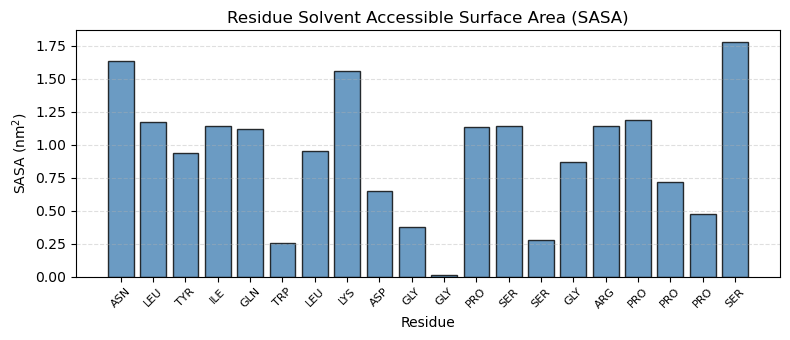

In [4]:
sasa_groups = msm.physchem.get_sasa(molsys, element='group', structure_indices=0)
sasa_vals = puw.get_value(sasa_groups[0], to_unit='nm**2')
group_names = msm.get(molsys, element='group', name=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(len(sasa_vals)), sasa_vals, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(sasa_vals)))
ax.set_xticklabels(group_names, rotation=45, fontsize=8)
ax.set_title('Residue Solvent Accessible Surface Area (SASA)')
ax.set_xlabel('Residue')
ax.set_ylabel('SASA (nm$^2$)')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()


## Total macromolecular SASA

Aggregating at the molecule level yields the total solvent-accessible area of the folded chain:


In [5]:
sasa_total = msm.physchem.get_sasa(molsys, element='molecule', structure_indices=0)
print('Total molecular SASA:', sasa_total[0, 0])


Total molecular SASA: 18.53787966629342 nanometer ** 2


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system attributes with {func}`molsysmt.basic.get`.
- {ref}`Get atomic radius <Tutorial_Get_atomic_radius>`: Query atomic radii with {func}`molsysmt.physchem.get_atomic_radius`.
- {ref}`Get buried fraction <Tutorial_Get_buried_fraction>`: Evaluate residue burial fractions with {func}`molsysmt.physchem.get_buried_fraction`.
:::
